In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load the data 
# (Make sure ethiopia.csv is inside your 'data' folder!)
df = pd.read_csv("data/tanzania.csv")

# 2. KPI: Add Country column
df["Country"] = "Tanzania"

# 3. KPI: Convert YEAR and DOY (Day of Year) into a proper datetime
# NASA uses %j for day of year (1-366)
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# 4. KPI: Extract Month for seasonal analysis
df["Month"] = df["Date"].dt.month

# 5. Preview the transformation
df.head()  

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


In [3]:
# 1. Define the columns to clean (prevents NameError)
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']

# 2. Replace NASA -999 values with NaN
df.replace(-999, np.nan, inplace=True)

# 3. Calculate Outliers (this looks for data spikes)
z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))

# 4. Clean and Export to the TANZANIA file
df[cols] = df[cols].ffill() # Fill gaps
df.to_csv("data/tanzania_clean.csv", index=False)
print("✅ Success! Check your data folder for tanzania_clean.csv")

✅ Success! Check your data folder for tanzania_clean.csv


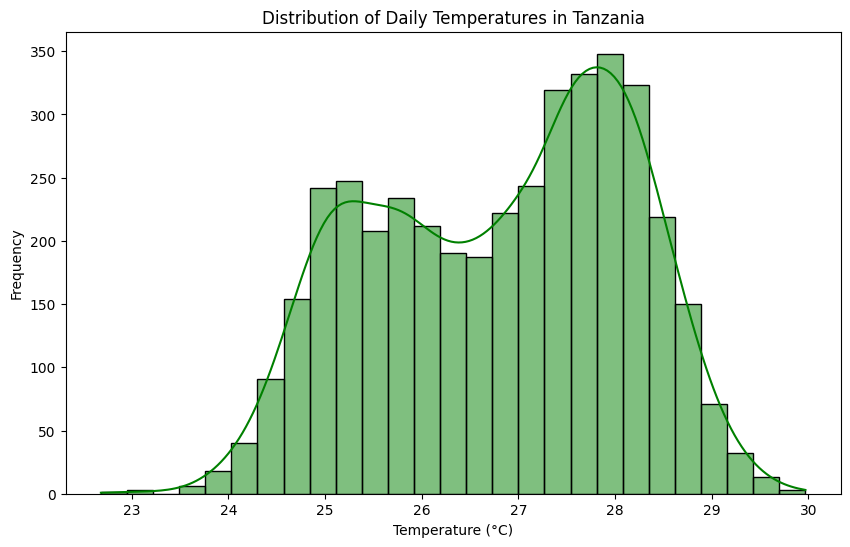

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['T2M'], kde=True, color='green')
plt.title('Distribution of Daily Temperatures in Tanzania')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

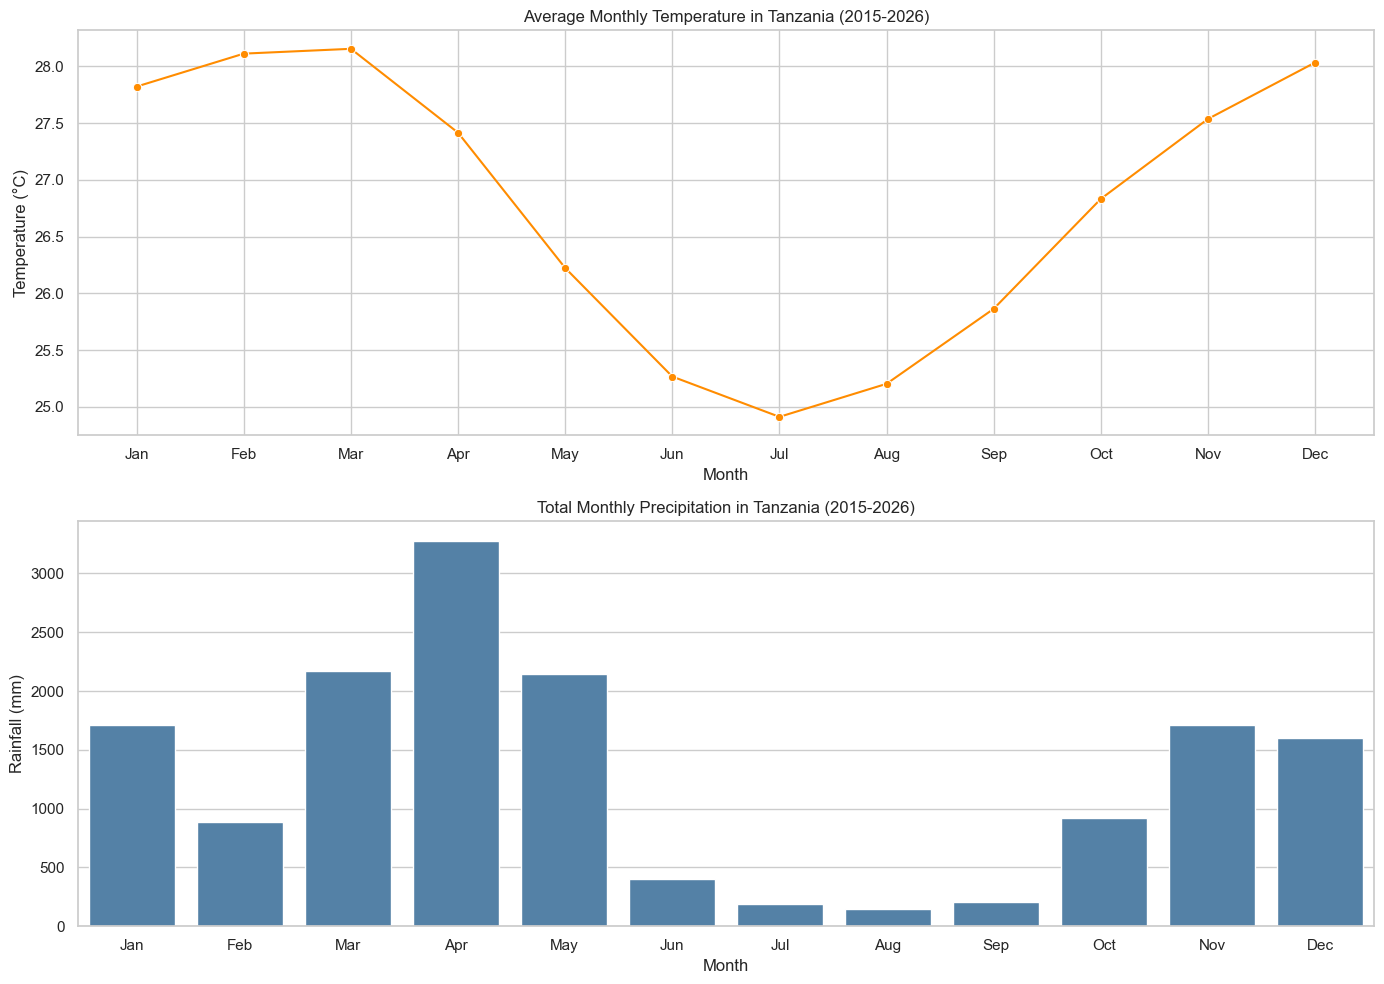

In [6]:
# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# Chart 1: Temperature Time Series (Monthly Average)
plt.subplot(2, 1, 1)
monthly_temp = df.groupby('Month')['T2M'].mean()
sns.lineplot(x=monthly_temp.index, y=monthly_temp.values, marker='o', color='darkorange')
plt.title('Average Monthly Temperature in Tanzania (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Chart 2: Precipitation (Monthly Total)
plt.subplot(2, 1, 2)
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum()
sns.barplot(x=monthly_rain.index, y=monthly_rain.values, color='steelblue')
plt.title('Total Monthly Precipitation in Tanzania (2015-2026)')
plt.ylabel('Rainfall (mm)')
plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

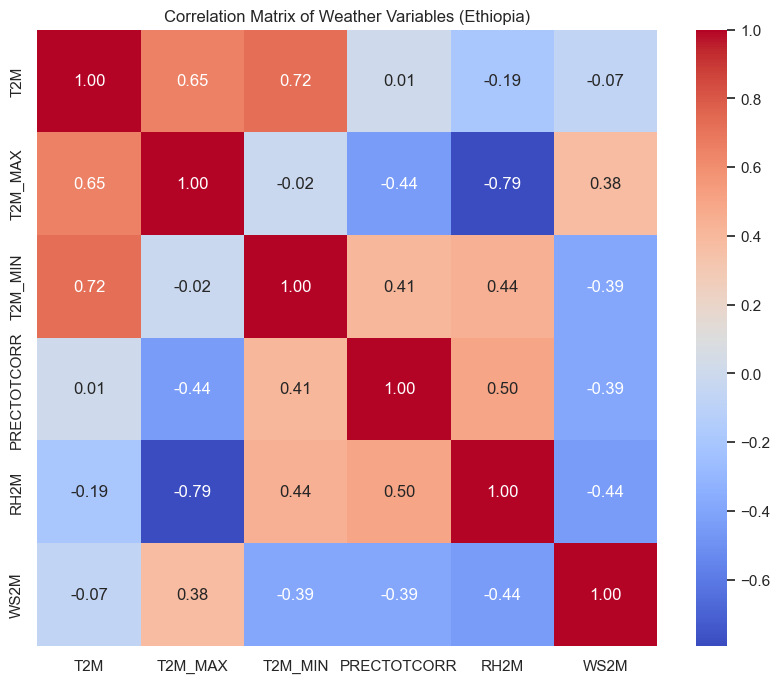

In [4]:
plt.figure(figsize=(10, 8))
# Select only the weather columns for the correlation
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
corr = df[weather_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Weather Variables (Ethiopia)')
plt.show()